https://www.spc.noaa.gov/exper/archive/event.php?date=20260310
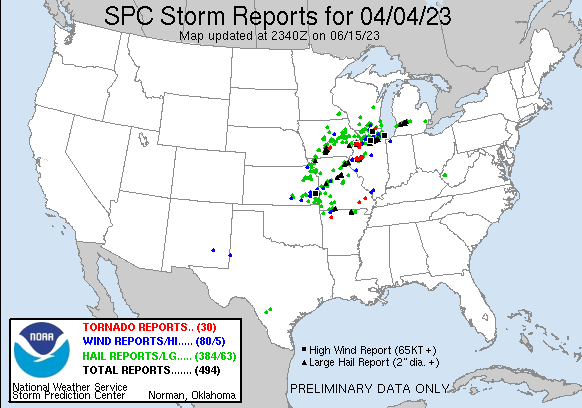 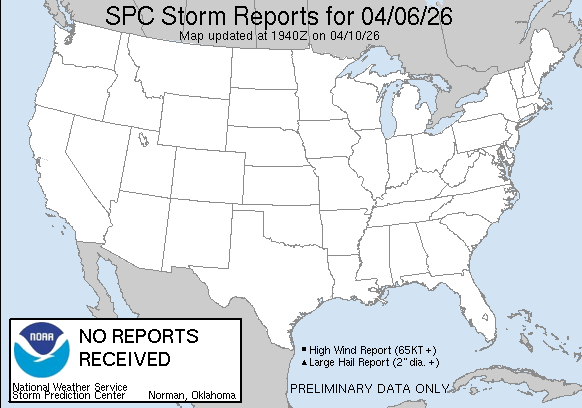

4 parameters? 
5 hour rolling
vertical velocty, cape, reflectivity, vil density

# Designing the Threat Index
Worked on by Myles, Manuel, and Jonathan.
- Focus for our threat index:

  The focus for our threat index is the optimal spot for dangerous hail formation. This would fall under the specific weather phenomenon category.
  
- Target audience:

  Our target audience is the general public because hail can impact anyone in the area where it falls. Our target audience is more specifically meteorologists who can utilize this scale in order to better predict hail and inform the general public of threats. 
  
- Scale or range chosen for our index:

  The scale we chose is based on our four variables, with the ones that affect hail the most being weighted the heaviest. When you check this threat index and see that a specific variable is heavily weighted on a given day, it indicates how much that variable influences hail severity. This helps you determine whether to expect severe hail on that day. The severity of hail is rated from 0 to 100, depending on the impact of these variables.

# Detailed Explanation of the formula and variables

Worked on by Jonathan.

- Our reasoning for choosing the variables?
The variables we chose include Vertically Integrated Liquid (VIL) Density, Reflectivity, CAPE, and Vertical Velocity. We chose the 5-hour rolling time for all these variables to account for the impact of storms on the short range HRRR. As for specific variables, the positive correlation between VIL Density and hail is proven. As the diameter of detected targets increases, so does the VIL density. Frequently, hydrometeor targets with high diameters indicate hail. Therefore, the connection between VIL Density and hail is evident. Reflectivity has a similar relationship - increasingly large hydrometeor targets are generally hail rather than raindrops. This "changeover" is generally around 50-70 dBZ, which is indicated in the formula for the reflectivity portion of the index. CAPE is short for Convective Available Potential Energy. Essentially, it describes a parcel's ability to rise freely based on atmospheric conditions and energy. The more CAPE is present, the more of a mechanism a parcel has to rise and eventually form a storm that would likely be conducive to producing hail. Lastly, vertical velocity is connected to hail in terms of the speed of the rising parcel - the faster the rising parcel, the more it can punch through any atmospheric CAP and form storms that are conducive to hail. 
  

- How the formula works and why it makes sense?
The formula is as follows: hail_index_calc = (cape_contribution * 0.20 + refc_contribution * 0.225 + vil_density_contribution * .35 + vert_velo_contribution * 0.225) * 100
The formula works by weighting four indexed variables, all taking on varying weights based on how closely correlated they are with the potential for hail. All of the variables are indexed individually from 0 to 1. The formula makes sense because it combines the contributions of all of the variables, multiplying by 100, in order to create an index from 0 to 100 that displays hail risk by location. 
  
- How each variable is weighted or combined?
Research used to inform our weighting: 
https://www.weather.gov/ohx/vildensityhailsize
https://www.weather.gov/media/wrh/online_publications/TAs/TA1005.pdf

Individual Variable Weightings: 
CAPE is indexed using a combination of constant ranges combined with a linearly increasing range in order to create an index that connects medium to large CAPE values with high chances of hail. The linear increase occurs between 1250 and 2500 J of CAPE, where CAPE becomes high enough to support hailstorms. 
Reflectivity is also indexed using a combination of constant ranges and a linearly increasing range. This is because at low values of reflectivity, hail is pretty much impossible. At high values of reflectivity, hail is very likely. At medium values of reflectivity, there is a sharp increase around 50-60 dBZ where hail becomes significantly more likely, hence where the linear increase is implemented. 
VIL Density is indexed using a small constant range, a large range of linear increase, and then another constant range. The VIL Density is indexed like this because there is a correlation between hydrometeor diameter and hail probability, and hydrometeor diameter is a significant factor in the VIL Density equation. Generally, VIL Density becomes viable for hail between 0.25 and 0.75 kg/m^2.
Vertical velocity is indexed using two linearly increasing fits and a constant range. It's indexed like this because vertical velocity has a positive correlation with hail probability up to a little over 1 m/s, when the hail probability stops increasing. 

Equation weightings: 
VIL Density is weighted the highest (*.35) because it has been proven to have a particularly significant correlation with hail probability (demonstrated in research cited above). It also is exceptionally good at highlighting very pinpointed areas of significant hail, with areas of high VIL Density lining up with storm reports from the event. Reflectivity and vertical velocity are weighted at 0.225. Reflectivity provides a significant correlation based on size of hydrometeors, but there can still be discrepancies due to very large raindrops or other flying items. Similarly, high vertical veloctiy is a good start if you want to see hail, but VIL Density seems to be an even stronger indicator. CAPE is weighted the least at 0.20. While definitely an important factor, high CAPE values span such a large area that it can only be so good of an indicator for hail reports and storms that can be hyperlocalized. 

  
  
- Why this index would be useful to our audience?
This index can be used by meteorologists to study the factors that correlate with hail. Once meteorologists have a better grasp on the factors that cause hail and are associated with hail, they can make more accurate and informed forecasts pertaining to hail risk. Hail can be very dangerous to person and property, so our audience's safety and livelihood would benefit from better meteorological knowledge about hail and how to predict it before it hits. 
  

In [2]:
#Code for the formula to calculate the index of the 4 NWP model variables worked on by Myles, Manuel, and Jonathan
from herbie import Herbie, FastHerbie
from herbie.toolbox import EasyMap, pc
from herbie import paint
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta, time, timezone
import pandas as pd, numpy as np
import xarray as xr
import dask

ds_file = xr.open_dataset("hrrr_2026031012.nc") #ds_file used to open the netcdf file in order for us to use the data to create plots
ds_file
ds_file = ds_file.rename({"unknown":"cloudtop"})

def map(): #map function used to create our base maps when needed
    fig = plt.figure(figsize=(12,9)) #figure size for us to place our base map
    ax = fig.add_subplot(111, projection=ccrs.LambertConformal()) #projection used for our base map
    ax.set_extent([-107,-79,26,44], ccrs.PlateCarree()) #set extent for our base map to zoom into our area of interest
    ax.add_feature(cfeature.COASTLINE) #coastlines added on our map 
    ax.add_feature(cfeature.STATES, linestyle=':')
    ax.add_feature(cfeature.BORDERS)
    return fig, ax

lon = ds_file['longitude'] #getting the longitude from our ds_file so we can plot our data
lat = ds_file['latitude'] #gettting the latitude from our ds_file so we can plot our data
dataproj = ccrs.PlateCarree() #making PlateCarree in our dataproj so we can add it to our pcolormesh

sh: 1: getfattr: not found


In [3]:
# Start with all contributions set to 0
vil_density =  (ds_file["veril"] /  ds_file["cloudtop"]) *100
vil_density_5hr_rolling = vil_density.rolling(valid_time=5).max()
def vil_density_index(ds_file,step): #created a function to make it easier to plot the index at different steps
# Start with all contributions set to 0
    vil_density_5hr_rolling_time =vil_density_5hr_rolling.isel(valid_time=step).values
    vil_density_contribution = np.zeros_like(vil_density_5hr_rolling_time)

    mask = (vil_density_5hr_rolling_time >= 0.25) & (vil_density_5hr_rolling_time < 1.75 )
    vil_density_contribution[mask] = (vil_density_5hr_rolling_time[mask] - 0.25) / 1.50

    mask = (vil_density_5hr_rolling_time >= 1.75) 
    vil_density_contribution[mask] = 1.0
    return vil_density_contribution

In [4]:
def refc_index(ds_file, step): #created a function to make it easier to plot the index at different steps
    refc_5hr_rolling = ds_file['refc'].rolling(valid_time=5).max()
    refc_5hr_rolling_time = refc_5hr_rolling.isel(valid_time=step).values
    refc_contribution = np.zeros_like(refc_5hr_rolling_time)

    # Setting the index = 0 if reflectivity is less than 45 
    mask = refc_5hr_rolling_time < 45
    refc_contribution[mask] = 0

    # Creating a linearly increasing index from 0 to 1, for reflectivity in betwene 45 and 60 (inclusive)
    mask = (refc_5hr_rolling_time >= 45) & (refc_5hr_rolling_time <= 60)
    refc_contribution[mask] = ((refc_5hr_rolling_time[mask] - 45) / 15)

    # Setting the index = 1 if reflectivty is greater than 60
    mask = refc_5hr_rolling_time > 60
    refc_contribution[mask] = 1
    return refc_contribution

In [5]:
def cape_index(ds_file,step): #created a function to make it easier to plot the index at different steps

    cape_5hr_rolling = ds_file['cape'].rolling(valid_time=5).max()
    cape_5hr_rolling_time = cape_5hr_rolling.isel(valid_time=step).values
    cape_contribution = np.zeros_like(cape_5hr_rolling_time)

    # Setting the index = 0 if CAPE is less than 1250
    mask = (cape_5hr_rolling_time < 1250)
    cape_contribution[mask] = 0

    # Creating a linearly increasing index from 0 to 1, for CAPE in between 1250 and 2500 (inclusive)
    mask = (cape_5hr_rolling_time >= 1250) & (cape_5hr_rolling_time <= 2500)
    cape_contribution[mask] = (cape_5hr_rolling_time[mask] - 1250) / 1250

    # Setting the index = 1 if CAPE is greater than 2500
    mask = cape_5hr_rolling_time > 2500
    cape_contribution[mask] = 1
    return cape_contribution

In [6]:
def vert_velo_index(ds_file,step): #created a function to make it easier to plot the index at different steps
#Vertical Velocity Parameter Index
    vert_velo_5hr_rolling = ds_file["wz"].rolling(valid_time=5).max()
    vert_velo_5hr_rolling_time = vert_velo_5hr_rolling.isel(valid_time=step).values
    vert_velo_contribution = np.zeros_like(vert_velo_5hr_rolling_time)

    mask = (vert_velo_5hr_rolling_time >= 0) & (vert_velo_5hr_rolling_time < 0.55)
    vert_velo_contribution[mask] = (vert_velo_5hr_rolling_time[mask] - 0) / 1.45

    mask = (vert_velo_5hr_rolling_time >= 0.55) & (vert_velo_5hr_rolling_time < 1.2)
    vert_velo_contribution[mask] = (vert_velo_5hr_rolling_time[mask] - 0.20) / 1

    mask = (vert_velo_5hr_rolling_time >= 1.2)
    vert_velo_contribution[mask] = 1
    return vert_velo_contribution

# Implement the Algorithm

In [7]:
#Code for implementing the algorithm function worked on by Myles, Jonathan, and Manuel
# Research used to inform our weighting: 
# https://www.weather.gov/ohx/vildensityhailsize
# https://www.weather.gov/media/wrh/online_publications/TAs/TA1005.pdf
def hail_index(ds_file,step):
    cape_5hr_rolling = ds_file['cape'].rolling(valid_time=5).max()
    cape_5hr_rolling_time = cape_5hr_rolling.isel(valid_time=step).values
    cape_contribution = np.zeros_like(cape_5hr_rolling_time)

    # Setting the index = 0 if CAPE is less than 1250
    mask = (cape_5hr_rolling_time < 1250)
    cape_contribution[mask] = 0

    # Creating a linearly increasing index from 0 to 1, for CAPE in between 1250 and 2500 (inclusive)
    mask = (cape_5hr_rolling_time >= 1250) & (cape_5hr_rolling_time <= 2500)
    cape_contribution[mask] = (cape_5hr_rolling_time[mask] - 1250) / 1250

    # Setting the index = 1 if CAPE is greater than 2500
    mask = cape_5hr_rolling_time > 2500
    cape_contribution[mask] = 1

    refc_5hr_rolling = ds_file['refc'].rolling(valid_time=5).max()
    refc_5hr_rolling_time = refc_5hr_rolling.isel(valid_time=step).values
    refc_contribution = np.zeros_like(refc_5hr_rolling_time)

    # Setting the index = 0 if reflectivity is less than 45 
    mask = refc_5hr_rolling_time < 45
    refc_contribution[mask] = 0

    # Creating a linearly increasing index from 0 to 1, for reflectivity in betwene 45 and 60 (inclusive)
    mask = (refc_5hr_rolling_time >= 45) & (refc_5hr_rolling_time <= 60)
    refc_contribution[mask] = ((refc_5hr_rolling_time[mask] - 45) / 15)

    # Setting the index = 1 if reflectivty is greater than 60
    mask = refc_5hr_rolling_time > 60
    refc_contribution[mask] = 1

    vil_density_5hr_rolling_time =vil_density_5hr_rolling.isel(valid_time=step).values
    vil_density_contribution = np.zeros_like(vil_density_5hr_rolling_time)

    mask = (vil_density_5hr_rolling_time >= 0.25) & (vil_density_5hr_rolling_time < 1.75 )
    vil_density_contribution[mask] = (vil_density_5hr_rolling_time[mask] - 0.25) / 1.50

    mask = (vil_density_5hr_rolling_time >= 1.75) 
    vil_density_contribution[mask] = 1.0

    #vert velo index being created
    vert_velo_5hr_rolling = ds_file["wz"].rolling(valid_time=5).max()
    vert_velo_5hr_rolling_time = vert_velo_5hr_rolling.isel(valid_time=step).values
    vert_velo_contribution = np.zeros_like(vert_velo_5hr_rolling_time)

    mask = (vert_velo_5hr_rolling_time >= 0) & (vert_velo_5hr_rolling_time < 0.55)
    vert_velo_contribution[mask] = (vert_velo_5hr_rolling_time[mask] - 0) / 1.45

    mask = (vert_velo_5hr_rolling_time >= 0.55) & (vert_velo_5hr_rolling_time < 1.2)
    vert_velo_contribution[mask] = (vert_velo_5hr_rolling_time[mask] - 0.20) / 1

    mask = (vert_velo_5hr_rolling_time >= 1.2)
    vert_velo_contribution[mask] = 1

    hail_index_calc = (cape_contribution * 0.20 + refc_contribution * 0.225 + vil_density_contribution * 0.35 + vert_velo_contribution * 0.225) * 100
    return hail_index_calc

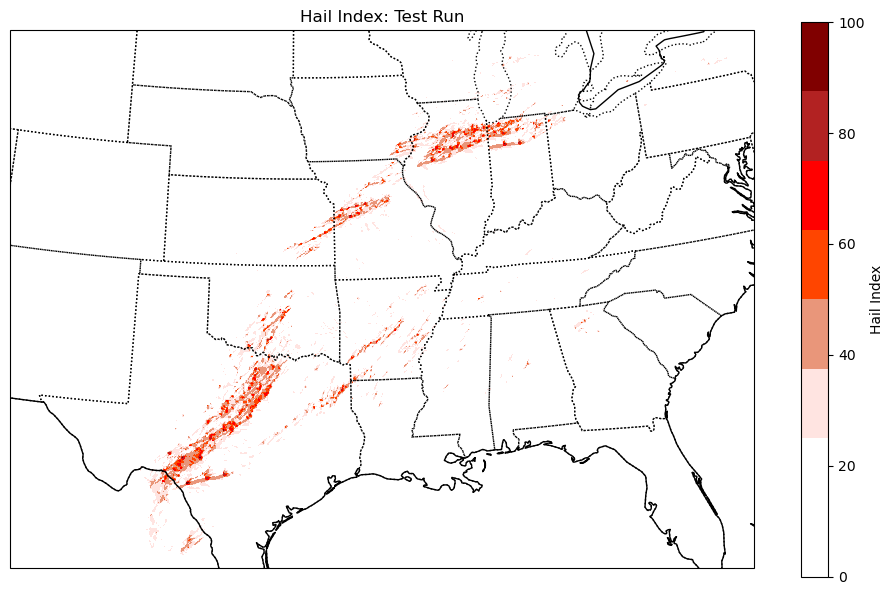

In [8]:
from matplotlib.colors import ListedColormap
custom_cmap = [ #from notebook.community
    "white", # ND
    "white", # -30
    "mistyrose", # -25
    "darksalmon", # -20
    "orangered", # -15
    "red", # -10
    "firebrick", # -5
    "maroon", # 0
    ]

realcmap = ListedColormap(custom_cmap, name='nws_reflectivity_colors')

fig,ax = map() #calling map function
pcolor3 = ax.pcolormesh(lon,lat, hail_index(ds_file,15), cmap= realcmap, vmax = 100, transform = dataproj) #creating pcolormesh map for hail index at step 15 to test the function
plt.colorbar(pcolor3, ax=ax, label = 'Hail Index', shrink = 0.8) #creating a colorbar for hail index to test it at step 15
plt.title("Hail Index: Test Run")
plt.show()

# Visualize the Output

In [9]:
#Code for visualizing the output worked on by Myles
#Used GeminiAI to figure out how to create the for loop for the function
def map2(rows,cols): #map function used to create our base maps when needed
    fig,axes = plt.subplots(rows,cols,figsize=(24,12),subplot_kw = {"projection":ccrs.LambertConformal()}) #figure size for us to place our base map
    flat_axes = axes.flatten() #used axes.flatten to make the loop simpler for the for loop
    for i, ax in enumerate(flat_axes): #for loop to enumerate the flat_axes or the list of subplots
        if i == 5: #this is to make sure there is only 5 maps and that it hides the 6th map being created.
            ax.set_visible(False)
            continue  
        ax.set_extent([-107,-79,26,44], ccrs.PlateCarree()) #set extent for our base map to zoom into our area of interest
        ax.add_feature(cfeature.COASTLINE) #coastlines added on our map 
        ax.add_feature(cfeature.STATES, linestyle=':')
        ax.add_feature(cfeature.BORDERS)
    plt.tight_layout() #used tight_layout to make sure everything aligns perfectly and that nothing overlaps
    return fig, axes

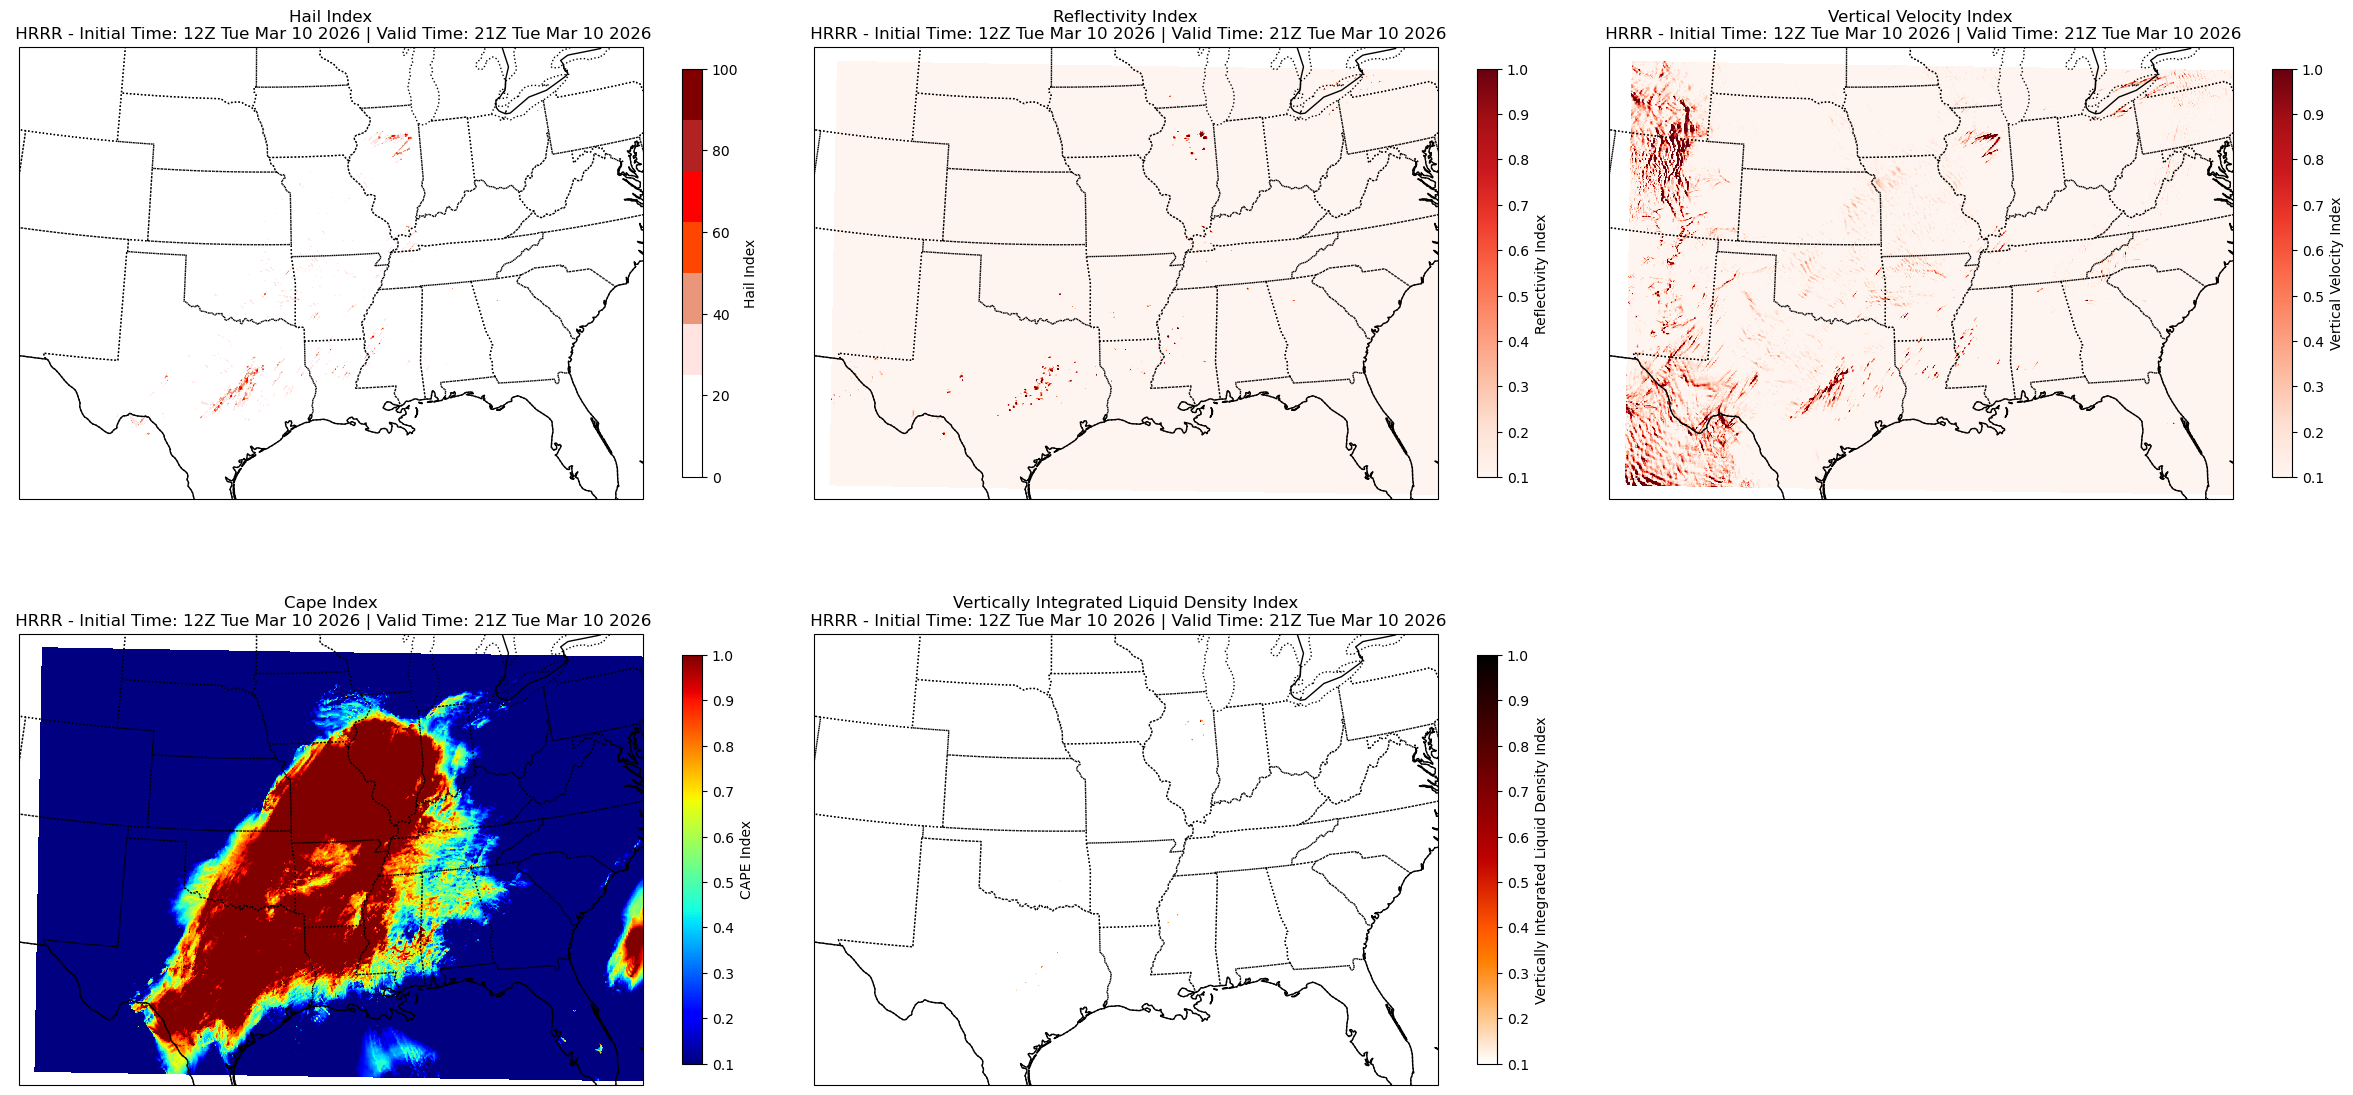

In [24]:
fig, axes = map2(2,3) #calling map2 function
pcolor4 = axes[0,0].pcolormesh(lon, lat, hail_index(ds_file,9), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 9
plt.colorbar(pcolor4, ax=axes[0,0], label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
axes[0,0].set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=9).values):%HZ %a %b %d %Y}") #title for map at step 9 with model name, valid time and initial time

pcolor5 = axes[1,0].pcolormesh(lon, lat, cape_index(ds_file,9), cmap = 'jet', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for cape index at step 9
plt.colorbar(pcolor5, ax=axes[1,0], label = 'CAPE Index', shrink = 0.7) #creating colorbar for the map
axes[1,0].set_title(f"Cape Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=9).values):%HZ %a %b %d %Y}") #title for map at step 9 with model name, valid time and initial time

pcolor6 = axes[0,1].pcolormesh(lon, lat, refc_index(ds_file,9), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for reflectivity index at step 9
plt.colorbar(pcolor6, ax=axes[0,1], label = 'Reflectivity Index', shrink = 0.7) #creating colorbar for the map
axes[0,1].set_title(f"Reflectivity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=9).values):%HZ %a %b %d %Y}") #title for map at step 9 with model name, valid time and initial time

pcolor7 = axes[1,1].pcolormesh(lon, lat, vil_density_index(ds_file,9), cmap = 'gist_heat_r', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vil density index at step 9
plt.colorbar(pcolor7, ax=axes[1,1], label = 'Vertically Integrated Liquid Density Index', shrink = 0.7) #creating colorbar for the map
axes[1,1].set_title(f"Vertically Integrated Liquid Density Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=9).values):%HZ %a %b %d %Y}") #title for map at step 9 with model name, valid time and initial time

pcolor8 =  axes[0,2].pcolormesh(lon, lat, vert_velo_index(ds_file,9), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vert velo index at step 9
plt.colorbar(pcolor8, ax=axes[0,2], label = 'Vertical Velocity Index', shrink = 0.7) #creating colorbar for the map
axes[0,2].set_title(f"Vertical Velocity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=9).values):%HZ %a %b %d %Y}") #title for map at step 9 with model name, valid time, and initial time
plt.show()

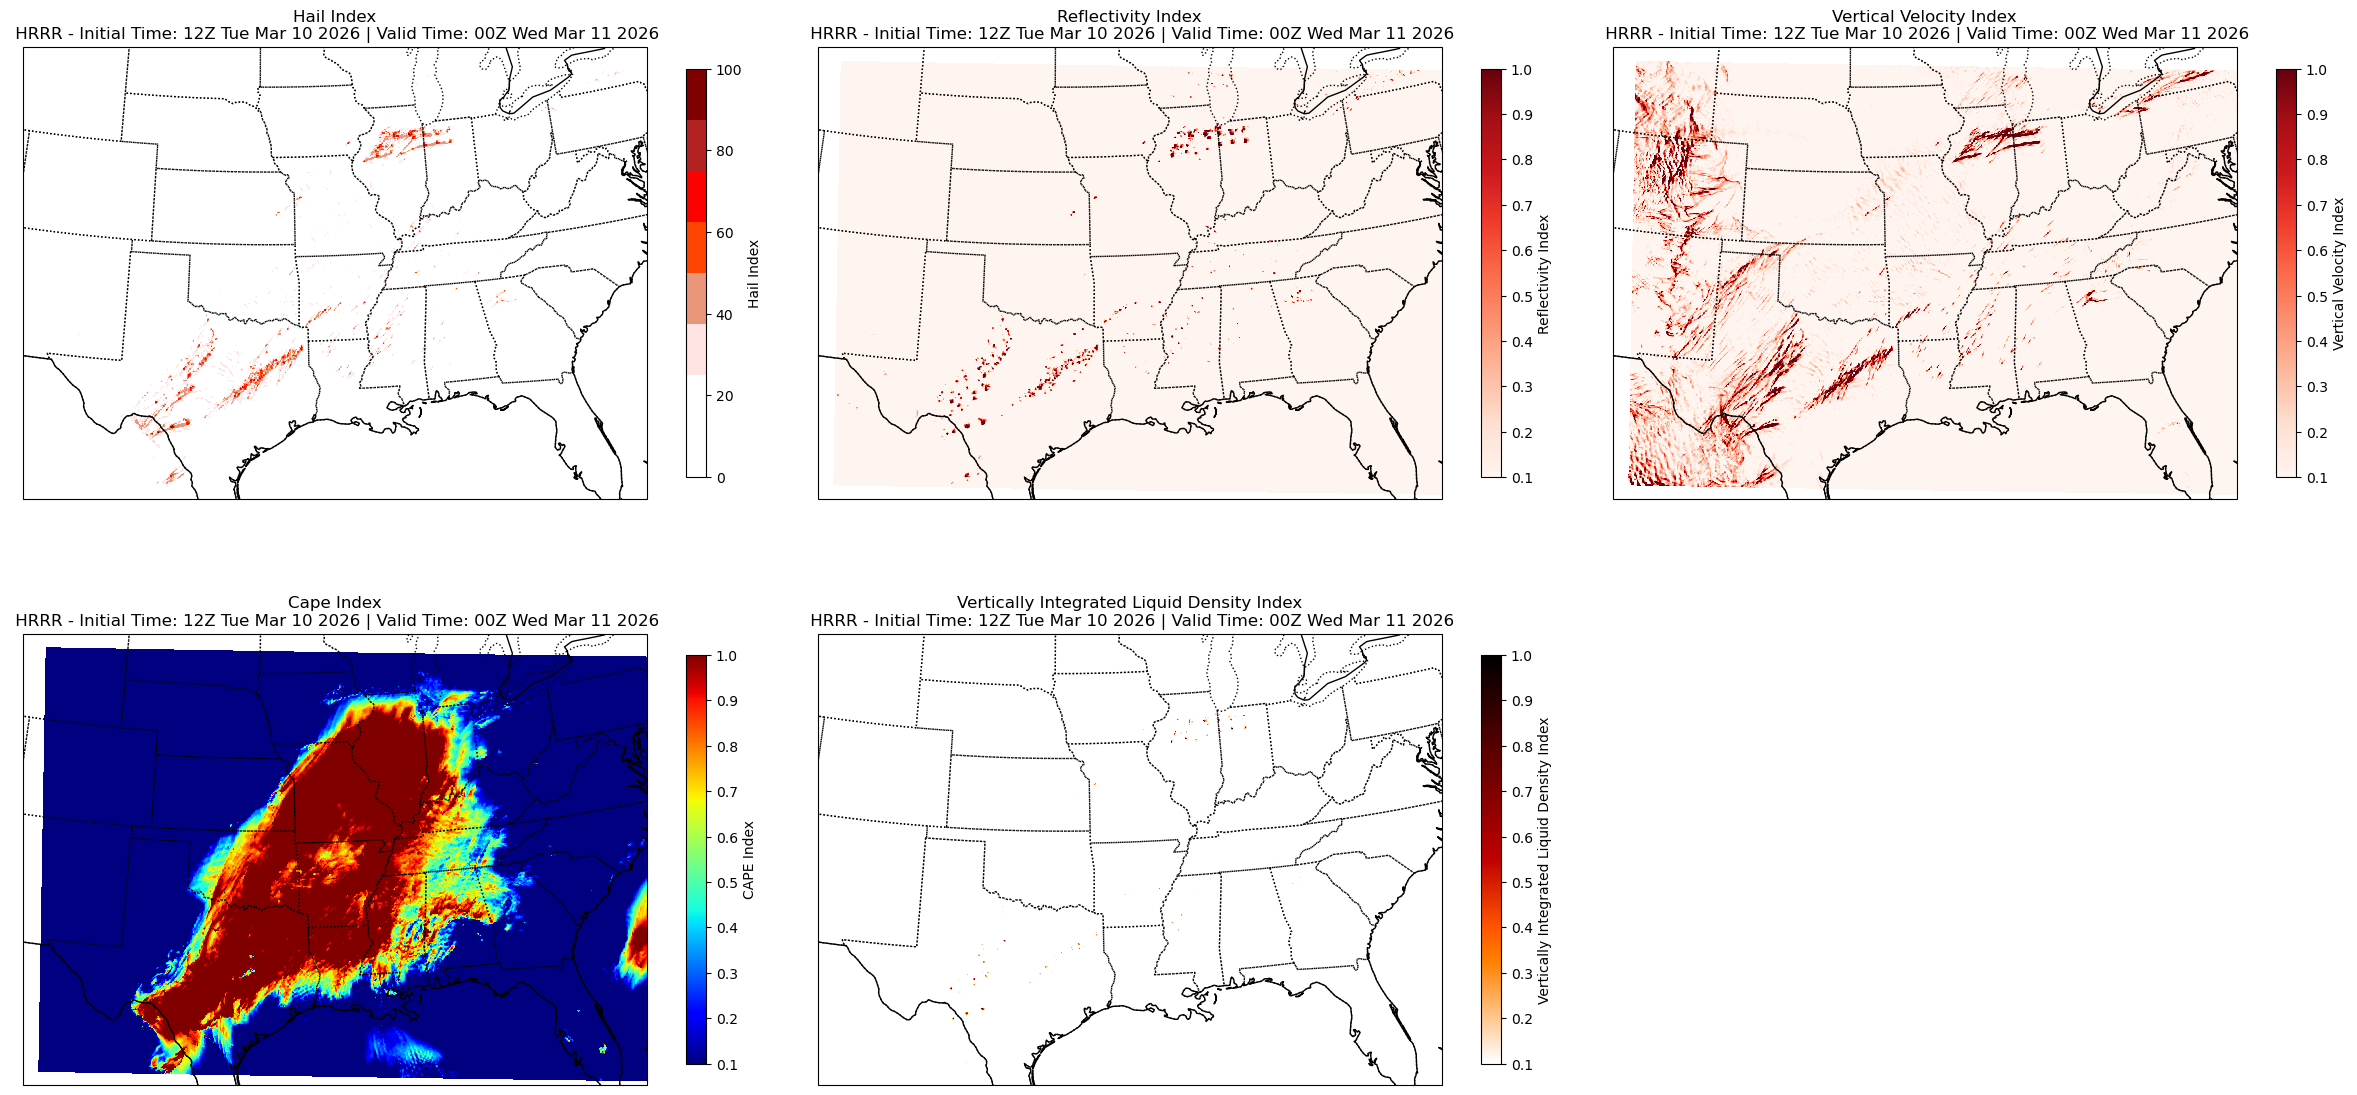

In [25]:
fig, axes = map2(2,3) #calling map2 function
pcolor9 = axes[0,0].pcolormesh(lon, lat, hail_index(ds_file,12), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 12
plt.colorbar(pcolor9, ax=axes[0,0], label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
axes[0,0].set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=12).values):%HZ %a %b %d %Y}") #title for map at step 12 with model name, valid time and initial time

pcolor10 = axes[1,0].pcolormesh(lon, lat, cape_index(ds_file,12), cmap = 'jet', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for cape index at step 12
plt.colorbar(pcolor10, ax=axes[1,0], label = 'CAPE Index', shrink = 0.7) #creating colorbar for the map
axes[1,0].set_title(f"Cape Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=12).values):%HZ %a %b %d %Y}") #title for map at step 12 with model name, valid time and initial time

pcolor11 = axes[0,1].pcolormesh(lon, lat, refc_index(ds_file,12), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for reflectivity index at step 12
plt.colorbar(pcolor11, ax=axes[0,1], label = 'Reflectivity Index', shrink = 0.7) #creating colorbar for the map
axes[0,1].set_title(f"Reflectivity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=12).values):%HZ %a %b %d %Y}") #title for map at step 12 with model name, valid time and initial time

pcolor12 = axes[1,1].pcolormesh(lon, lat, vil_density_index(ds_file,12), cmap = 'gist_heat_r', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vil density index at step 12
plt.colorbar(pcolor12, ax=axes[1,1], label = 'Vertically Integrated Liquid Density Index', shrink = 0.7) #creating colorbar for the map
axes[1,1].set_title(f"Vertically Integrated Liquid Density Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=12).values):%HZ %a %b %d %Y}") #title for map at step 12 with model name, valid time and initial time

pcolor13 =  axes[0,2].pcolormesh(lon, lat, vert_velo_index(ds_file,12), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vert velo density index at step 12
plt.colorbar(pcolor13, ax=axes[0,2], label = 'Vertical Velocity Index', shrink = 0.7) #creating colorbar for the map
axes[0,2].set_title(f"Vertical Velocity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=12).values):%HZ %a %b %d %Y}") #title for map at step 12 with model name, valid time and initial time
plt.show()

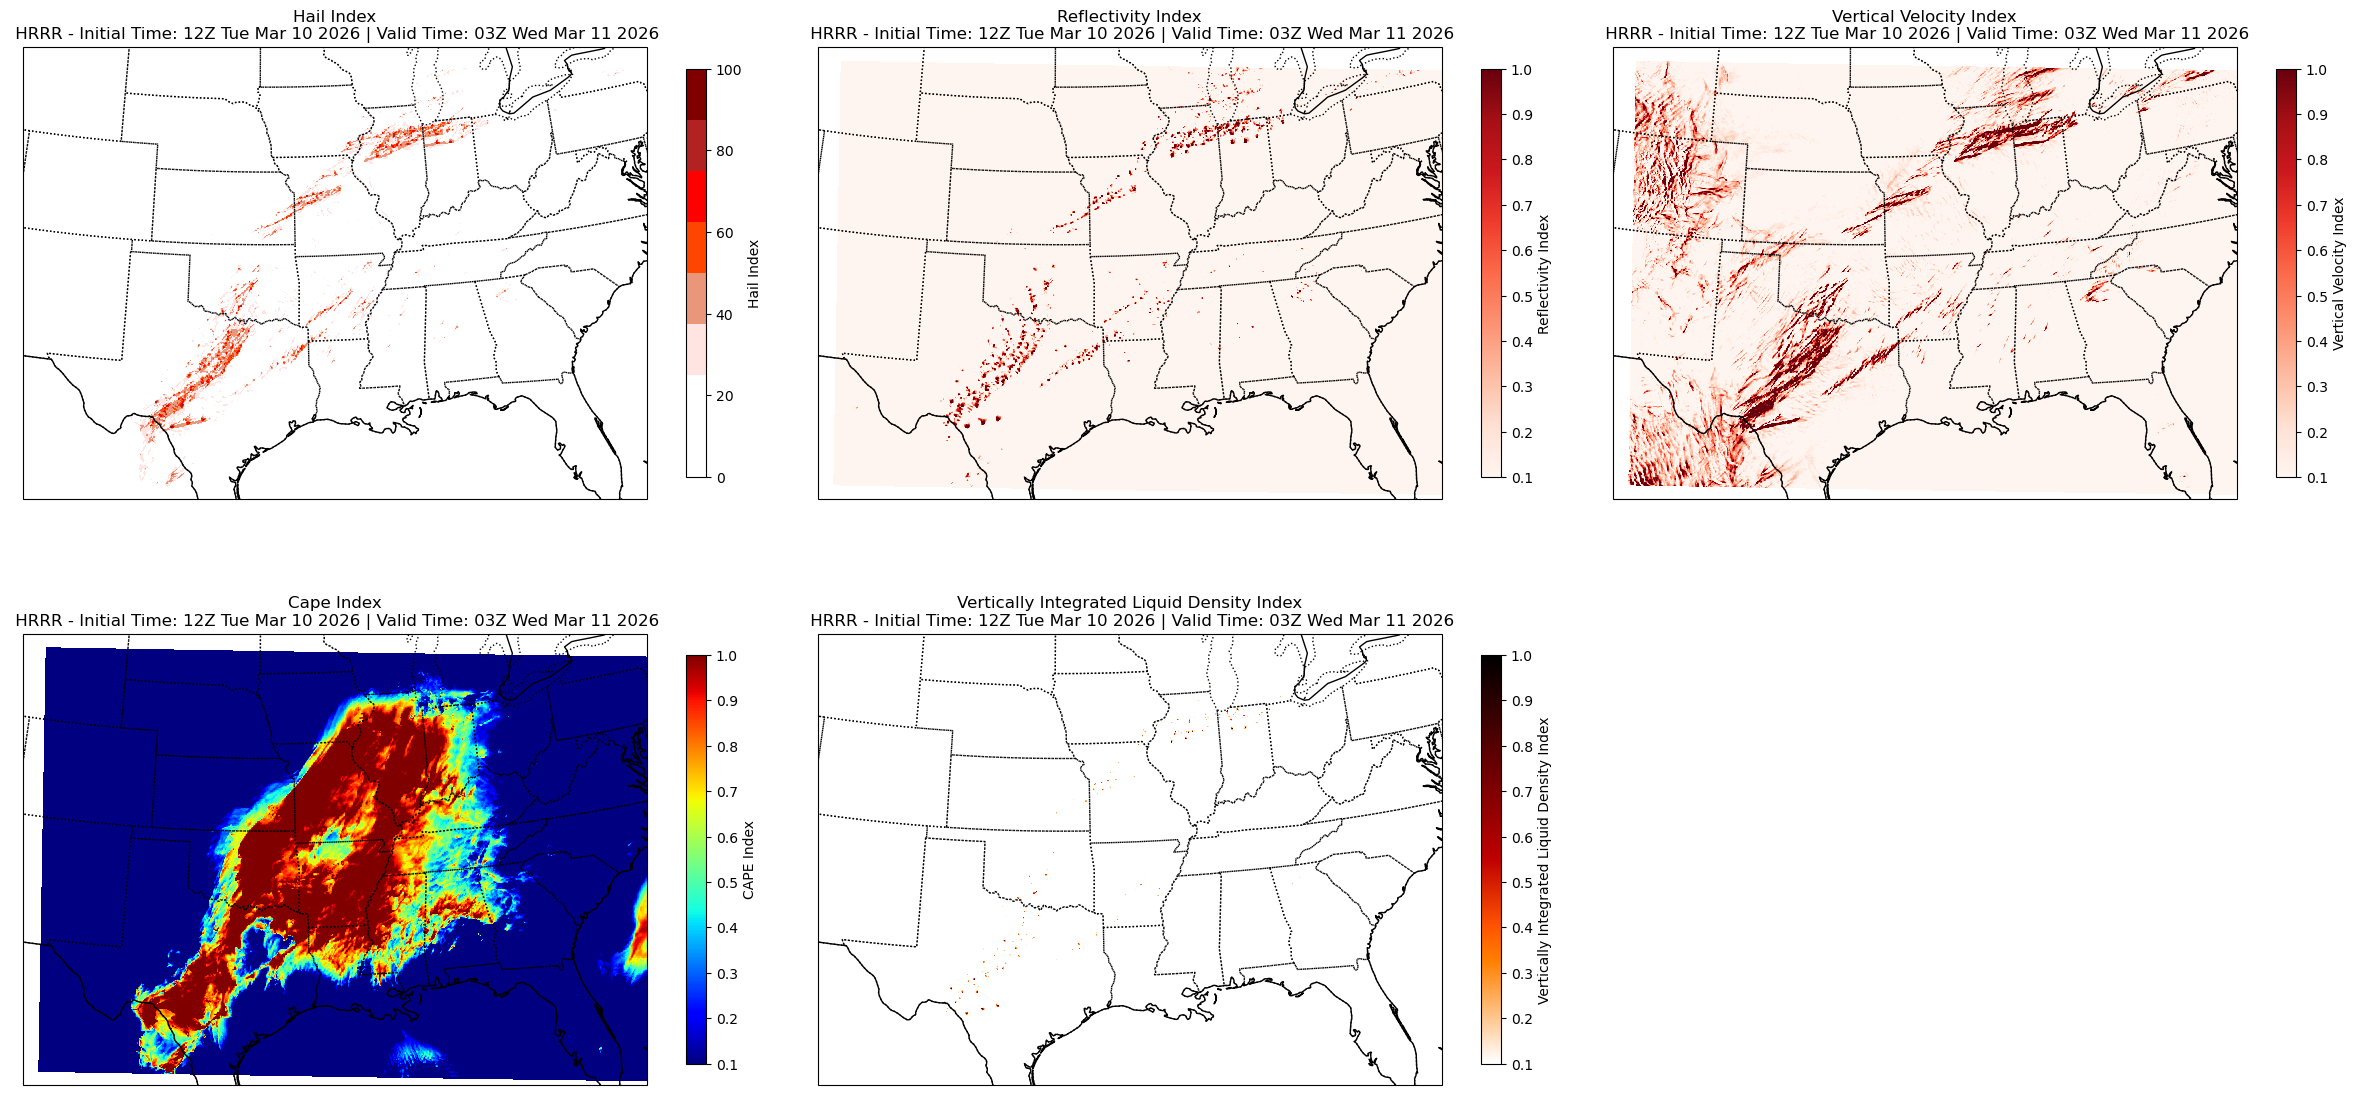

In [26]:
fig, axes = map2(2,3) #calling map2 function
pcolor14 = axes[0,0].pcolormesh(lon, lat, hail_index(ds_file,15), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 15
plt.colorbar(pcolor14, ax=axes[0,0], label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
axes[0,0].set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d %Y}") #title for map at step 15 with model name, valid time and initial time

pcolor15 = axes[1,0].pcolormesh(lon, lat, cape_index(ds_file,15), cmap = 'jet', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for the cape index at step 15
plt.colorbar(pcolor15, ax=axes[1,0], label = 'CAPE Index', shrink = 0.7) #creating colorbar for the map
axes[1,0].set_title(f"Cape Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d %Y}") #title for map at step 15 with model name, valid time and initial time

pcolor16 = axes[0,1].pcolormesh(lon, lat, refc_index(ds_file,15), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for the reflectivity index at step 15
plt.colorbar(pcolor16, ax=axes[0,1], label = 'Reflectivity Index', shrink = 0.7) #creating colorbar for the map
axes[0,1].set_title(f"Reflectivity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d %Y}") #title for map at step 15 with model name, valid time and initial time

pcolor17 = axes[1,1].pcolormesh(lon, lat, vil_density_index(ds_file,15), cmap = 'gist_heat_r', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vil density index at step 15
plt.colorbar(pcolor17, ax=axes[1,1], label = 'Vertically Integrated Liquid Density Index', shrink = 0.7) #creating colorbar for the map
axes[1,1].set_title(f"Vertically Integrated Liquid Density Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d %Y}") #title for map at step 15 with model name, valid time and initial time

pcolor18 =  axes[0,2].pcolormesh(lon, lat, vert_velo_index(ds_file,15), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vert velo index at step 15
plt.colorbar(pcolor18, ax=axes[0,2], label = 'Vertical Velocity Index', shrink = 0.7) #creating colorbar for the map
axes[0,2].set_title(f"Vertical Velocity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d %Y}") #title for map at step 15 with model name, valid time and initial time
plt.show()

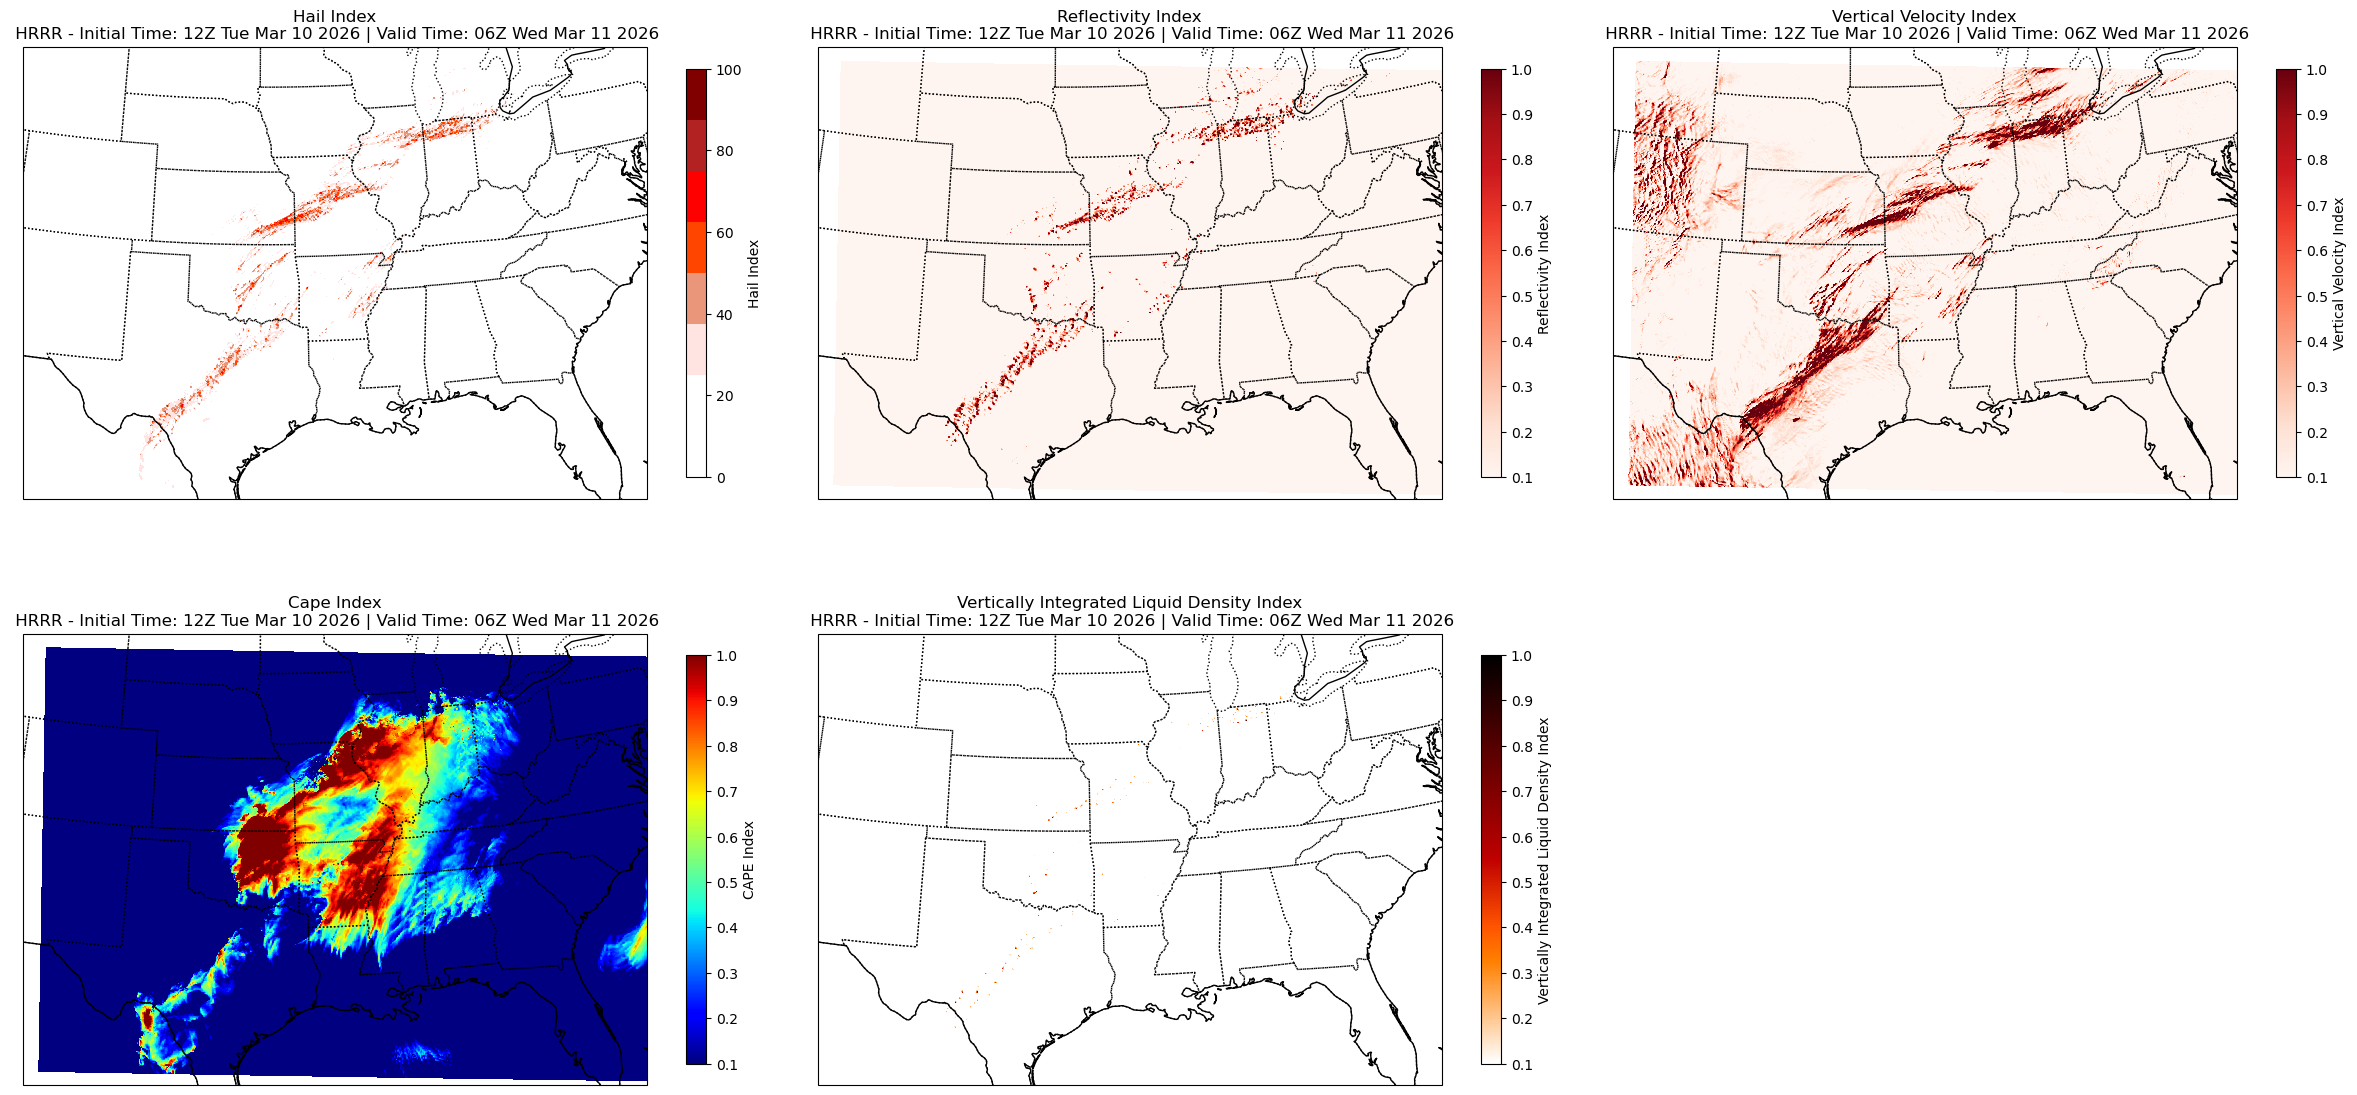

In [27]:
fig, axes = map2(2,3) #calling map2 function
pcolor19 = axes[0,0].pcolormesh(lon, lat, hail_index(ds_file,18), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 18
plt.colorbar(pcolor19, ax=axes[0,0], label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
axes[0,0].set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=18).values):%HZ %a %b %d %Y}") #title for map at step 18 with model name, valid time and initial time

pcolor20 = axes[1,0].pcolormesh(lon, lat, cape_index(ds_file,18), cmap = 'jet', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for cape index at step 18
plt.colorbar(pcolor20, ax=axes[1,0], label = 'CAPE Index', shrink = 0.7) #creating colorbar for the map
axes[1,0].set_title(f"Cape Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=18).values):%HZ %a %b %d %Y}") #title for map at step 18 with model name, valid time and initial time

pcolor21 = axes[0,1].pcolormesh(lon, lat, refc_index(ds_file,18), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for reflectivity index at step 18
plt.colorbar(pcolor21, ax=axes[0,1], label = 'Reflectivity Index', shrink = 0.7) #creating colorbar for the map
axes[0,1].set_title(f"Reflectivity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=18).values):%HZ %a %b %d %Y}") #title for map at step 18 with model name, valid time and initial time

pcolor22 = axes[1,1].pcolormesh(lon, lat, vil_density_index(ds_file,18), cmap = 'gist_heat_r', vmin = 0.1, vmax = 1, transform = dataproj) #creating a pcolormesh map for vil density index at step 18
plt.colorbar(pcolor22, ax=axes[1,1], label = 'Vertically Integrated Liquid Density Index', shrink = 0.7) #creating colorbar for the map
axes[1,1].set_title(f"Vertically Integrated Liquid Density Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=18).values):%HZ %a %b %d %Y}") #title for map at step 18 with model name, valid time and initial time

pcolor23 =  axes[0,2].pcolormesh(lon, lat, vert_velo_index(ds_file,18), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vert velo index at step 18
plt.colorbar(pcolor23, ax=axes[0,2], label = 'Vertical Velocity Index', shrink = 0.7) #creating colorbar for the map
axes[0,2].set_title(f"Vertical Velocity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=18).values):%HZ %a %b %d %Y}") #title for map at step 18 with model name, valid time and initial time
plt.show()

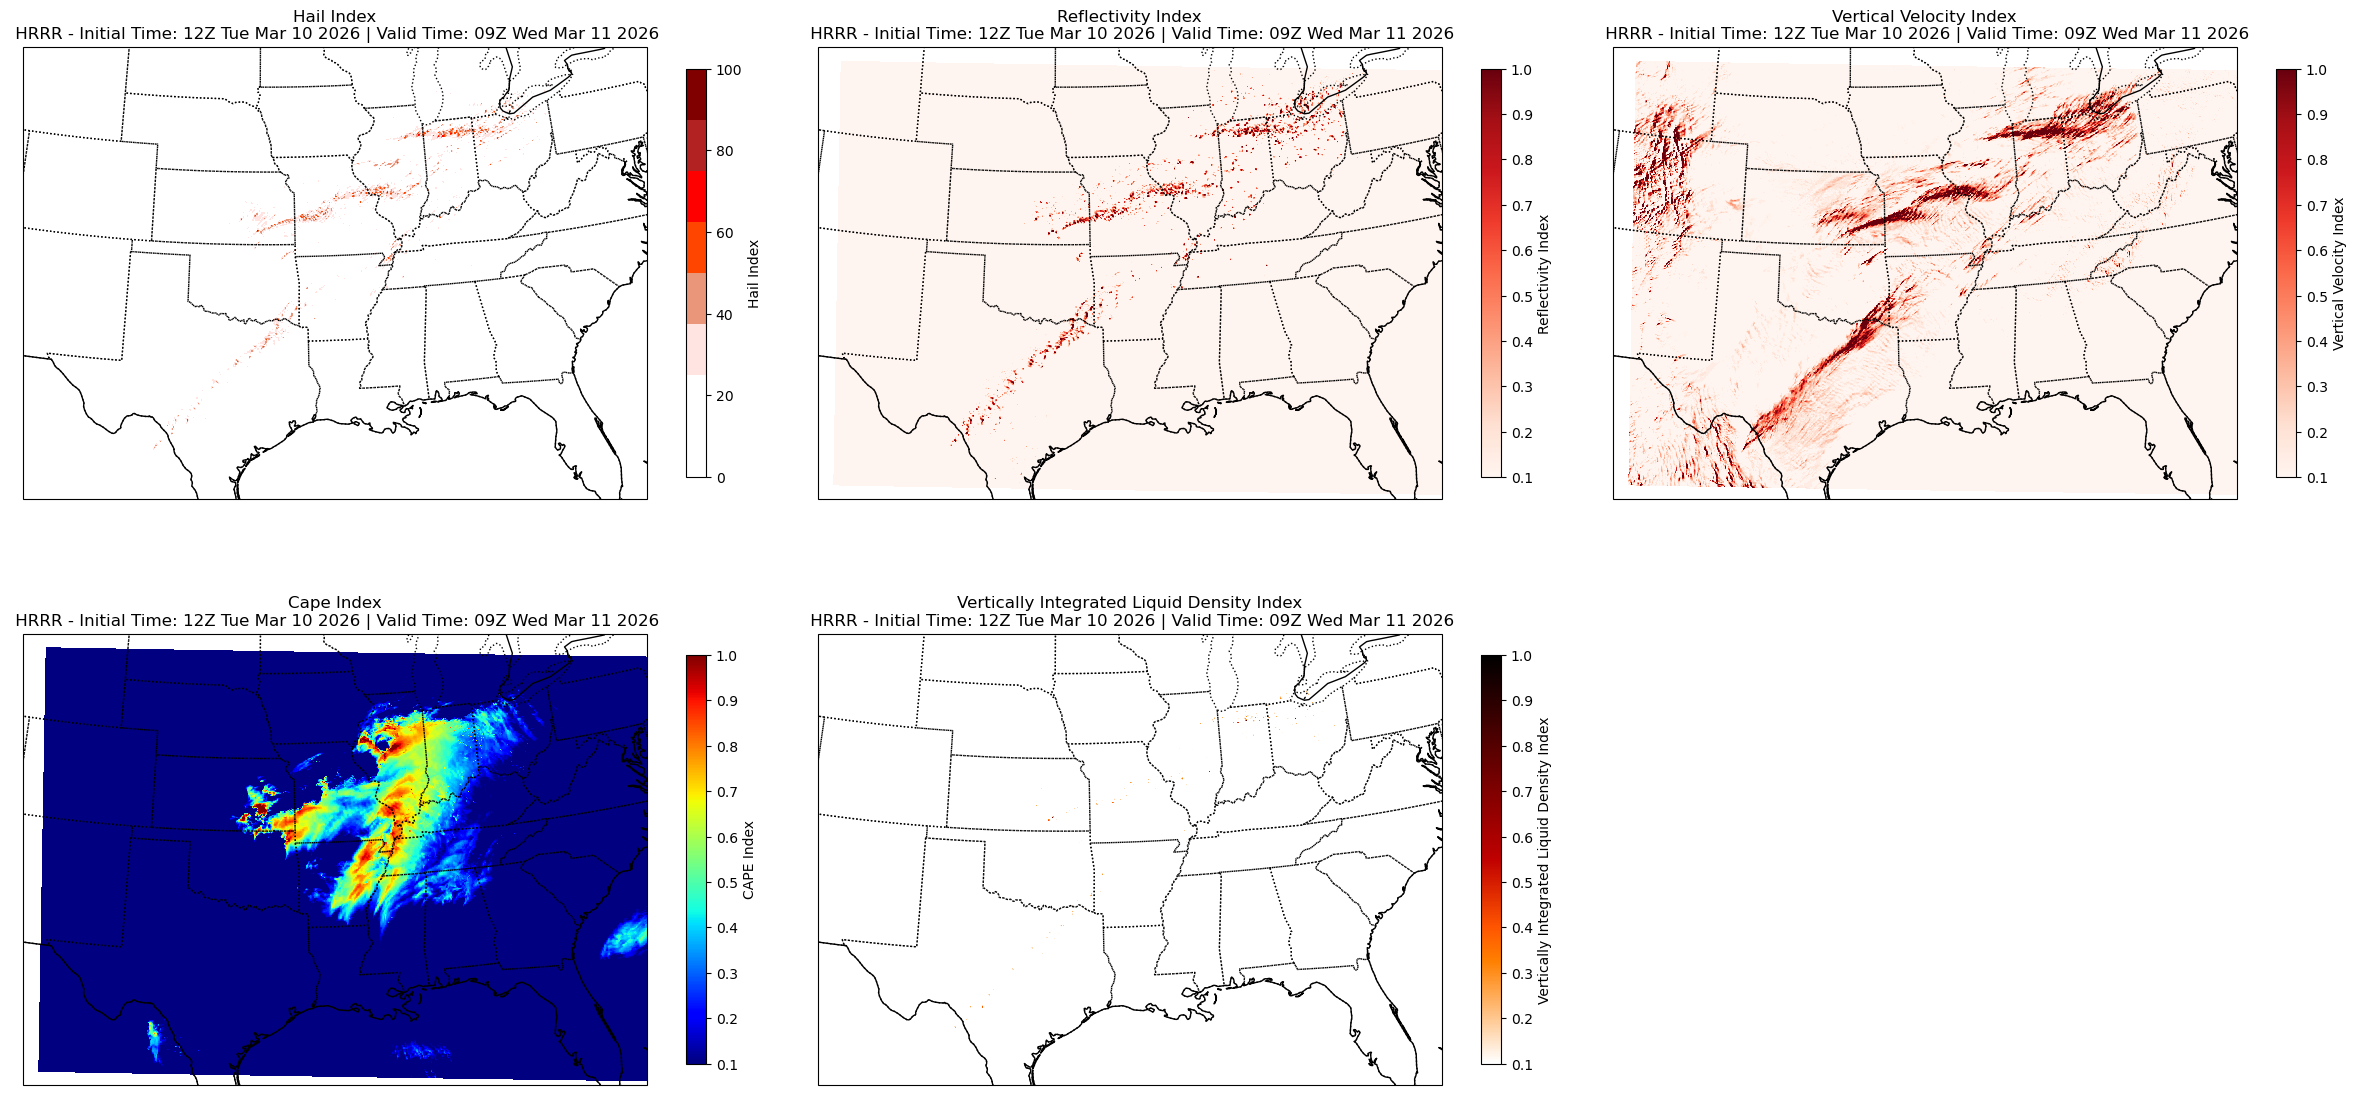

In [28]:
fig, axes = map2(2,3) #calling map2 function
pcolor24 = axes[0,0].pcolormesh(lon, lat, hail_index(ds_file,21), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 21
plt.colorbar(pcolor24, ax=axes[0,0], label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
axes[0,0].set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=21).values):%HZ %a %b %d %Y}") #title for map at step 21 with model name, valid time and initial time

pcolor25 = axes[1,0].pcolormesh(lon, lat, cape_index(ds_file,21), cmap = 'jet', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for cape index at step 21
plt.colorbar(pcolor25, ax=axes[1,0], label = 'CAPE Index', shrink = 0.7) #creating colorbar for the map
axes[1,0].set_title(f"Cape Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=21).values):%HZ %a %b %d %Y}") #title for map at step 21 with model name, valid time and initial time

pcolor26 = axes[0,1].pcolormesh(lon, lat, refc_index(ds_file,21), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for reflectivity index at step 21
plt.colorbar(pcolor26, ax=axes[0,1], label = 'Reflectivity Index', shrink = 0.7) #creating colorbar for the map
axes[0,1].set_title(f"Reflectivity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=21).values):%HZ %a %b %d %Y}") #title for map at step 21 with model name, valid time and initial time

pcolor27 = axes[1,1].pcolormesh(lon, lat, vil_density_index(ds_file,21), cmap = 'gist_heat_r', vmin = 0.1, vmax = 1, transform = dataproj) #creating a pcolormesh map for vil density index at step 21
plt.colorbar(pcolor27, ax=axes[1,1], label = 'Vertically Integrated Liquid Density Index', shrink = 0.7) #creating colorbar for the map
axes[1,1].set_title(f"Vertically Integrated Liquid Density Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=21).values):%HZ %a %b %d %Y}") #title for map at step 21 with model name, valid time and initial time

pcolor28 =  axes[0,2].pcolormesh(lon, lat, vert_velo_index(ds_file,21), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vert velo index at step 21
plt.colorbar(pcolor28, ax=axes[0,2], label = 'Vertical Velocity Index', shrink = 0.7) #creating colorbar for the map
axes[0,2].set_title(f"Vertical Velocity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=21).values):%HZ %a %b %d %Y}") #title for map at step 21 with model name, valid time and initial time
plt.show()

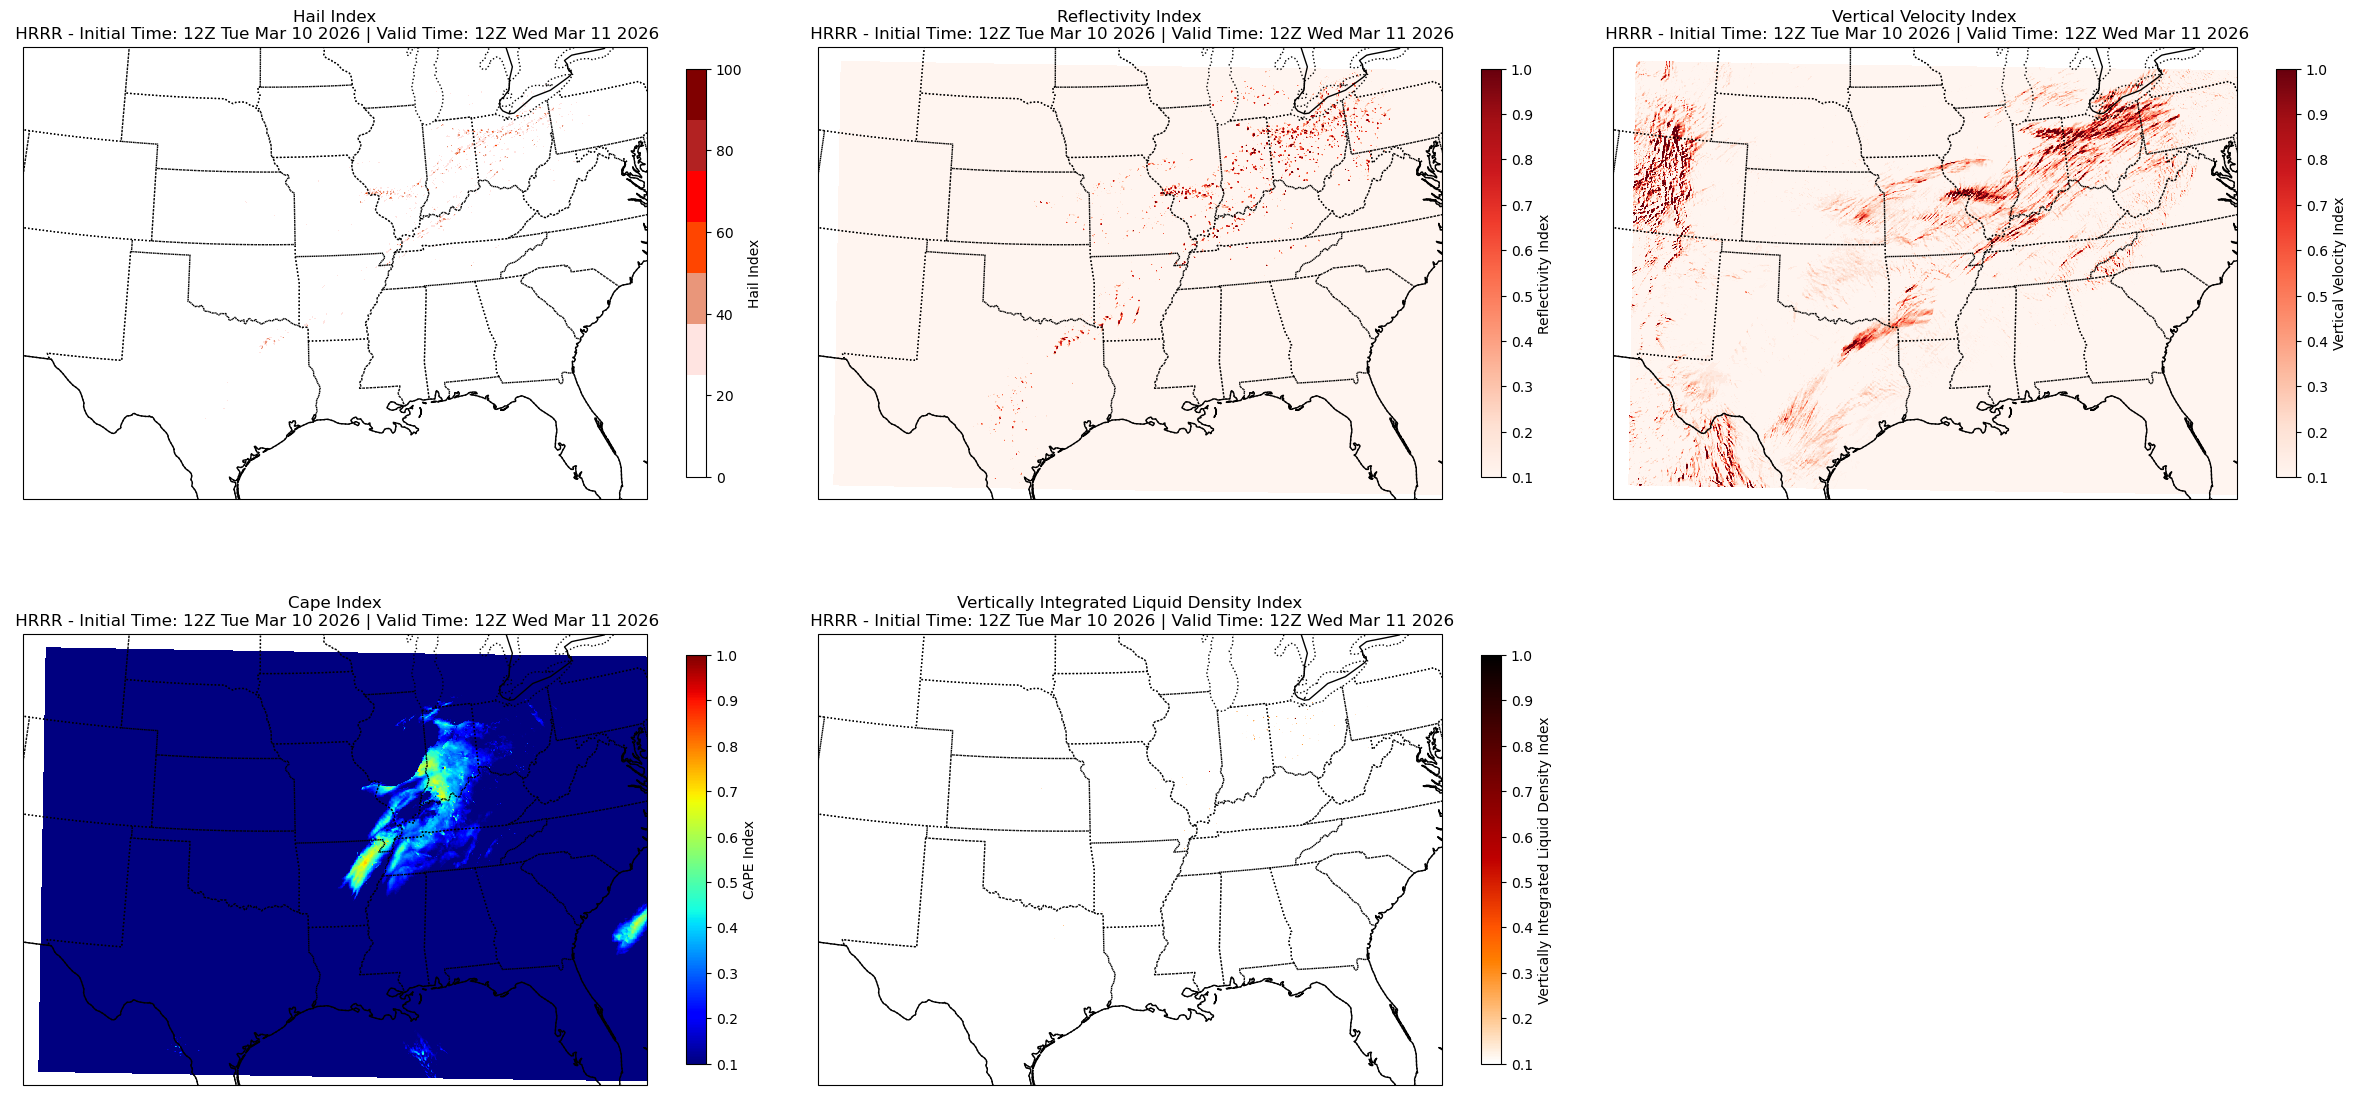

In [29]:
fig, axes = map2(2,3) #calling map2 function
pcolor29 = axes[0,0].pcolormesh(lon, lat, hail_index(ds_file,24), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 24
plt.colorbar(pcolor29, ax=axes[0,0], label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
axes[0,0].set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=24).values):%HZ %a %b %d %Y}") #title for map at step 24 with model name, valid time and initial time

pcolor30 = axes[1,0].pcolormesh(lon, lat, cape_index(ds_file,24), cmap = 'jet', vmin = 0.1, vmax = 1, transform = dataproj) #creating a pcolormesh map for cape index at step 24
plt.colorbar(pcolor30, ax=axes[1,0], label = 'CAPE Index', shrink = 0.7) #creating colorbar for the map
axes[1,0].set_title(f"Cape Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=24).values):%HZ %a %b %d %Y}") #title for map at step 24 with model name, valid time and initial time

pcolor31 = axes[0,1].pcolormesh(lon, lat, refc_index(ds_file,24), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for reflectivity index at step 24
plt.colorbar(pcolor31, ax=axes[0,1], label = 'Reflectivity Index', shrink = 0.7) #creating colorbar for the map
axes[0,1].set_title(f"Reflectivity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=24).values):%HZ %a %b %d %Y}") #title for map at step 24 with model name, valid time and initial time

pcolor32 = axes[1,1].pcolormesh(lon, lat, vil_density_index(ds_file,24), cmap = 'gist_heat_r', vmin = 0.1, vmax = 1, transform = dataproj) #creating a pcolormesh map for vil density index at step 24
plt.colorbar(pcolor32, ax=axes[1,1], label = 'Vertically Integrated Liquid Density Index', shrink = 0.7) #creating colorbar for the map
axes[1,1].set_title(f"Vertically Integrated Liquid Density Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=24).values):%HZ %a %b %d %Y}") #title for map at step 24 with model name, valid time and initial time

pcolor33 =  axes[0,2].pcolormesh(lon, lat, vert_velo_index(ds_file,24), cmap = 'Reds', vmin = 0.1, transform = dataproj) #creating a pcolormesh map for vert velo index at step 24
plt.colorbar(pcolor33, ax=axes[0,2], label = 'Vertical Velocity Index', shrink = 0.7) #creating colorbar for the map
axes[0,2].set_title(f"Vertical Velocity Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=24).values):%HZ %a %b %d %Y}") #title for map at step 24 with model name, valid time and initial time
plt.show()

# Test the Algorithm on Additional Events

In [16]:
#Code for testing the algorithm on additional events worked on by Manuel
ds_highend_file = xr.open_dataset("hrrr_2023040412.nc") #ds_highend_file used to open the netcdf file for us to plot the second high end case
ds_highend_file = ds_highend_file.rename({"unknown":"cloudtop"}) #cloudtops shows up as unknown and renaming it makes the data set easier to work with

#5 hour rolling products for the high-end case
refc_5hr_rolling_highend = ds_highend_file["refc"].rolling(valid_time=5).max()
cape_5hr_rolling_highend = ds_highend_file["cape"].rolling(valid_time=5).max()
vert_velo_5hr_rolling_highend = ds_highend_file["wz"].rolling(valid_time=5).max()
veril_5hr_rolling_highend =ds_highend_file["veril"].rolling(valid_time=5).max()
#derived products for high end
vil_density_highend =  (ds_highend_file["veril"] /  ds_highend_file["cloudtop"]) *100
vil_density_5hr_rolling_highend = vil_density_highend.rolling(valid_time=5).max()




sh: 1: getfattr: not found


In [17]:
#making the individual indecies for the high end case
# Start with all contributions set to 0 for vil density
vil_density_5hr_rolling_highend_time = vil_density_5hr_rolling_highend.isel(valid_time=15).values
vil_density_contribution_highend = np.zeros_like(vil_density_5hr_rolling_highend_time)


mask = (vil_density_5hr_rolling_highend_time >= 0.25) & (vil_density_5hr_rolling_highend_time < 1.75 )
vil_density_contribution_highend[mask] = (vil_density_5hr_rolling_highend_time[mask] - 0.25) / 1.50

mask = (vil_density_5hr_rolling_highend_time >= 1.75) 
vil_density_contribution_highend[mask] = 1

#refc index
refc_5hr_rolling_highend_time = refc_5hr_rolling_highend.isel(valid_time=15).values
refc_contribution_highend = np.zeros_like(refc_5hr_rolling_highend_time)

# Setting the index = 0 if reflectivity is less than 45 
mask = refc_5hr_rolling_highend_time < 45
refc_contribution_highend[mask] = 0

# Creating a linearly increasing index from 0 to 1, for reflectivity in betwene 45 and 60 (inclusive)
mask = (refc_5hr_rolling_highend_time >= 45) & (refc_5hr_rolling_highend_time <= 60)
refc_contribution_highend[mask] = ((refc_5hr_rolling_highend_time[mask] - 45) / 15)

# Setting the index = 1 if reflectivty is greater than 60
mask = refc_5hr_rolling_highend_time > 60
refc_contribution_highend[mask] = 1

#cape index
cape_5hr_rolling_highend_time = cape_5hr_rolling_highend.isel(valid_time=15).values
cape_contribution_highend = np.zeros_like(cape_5hr_rolling_highend_time)

# Setting the index = 0 if CAPE is less than 1250
mask = (cape_5hr_rolling_highend_time < 1250)
cape_contribution_highend[mask] = 0

# Creating a linearly increasing index from 0 to 1, for CAPE in between 1250 and 2500 (inclusive)
mask = (cape_5hr_rolling_highend_time >= 1250) & (cape_5hr_rolling_highend_time <= 2500)
cape_contribution_highend[mask] = (cape_5hr_rolling_highend_time[mask] - 1250) / 1250

# Setting the index = 1 if CAPE is greater than 2500
mask = cape_5hr_rolling_highend_time > 2500
cape_contribution_highend[mask] = 1

#vertical velocity parameter index
vert_velo_5hr_rolling_highend_time = vert_velo_5hr_rolling_highend.isel(valid_time=15).values
vert_velo_contribution_highend = np.zeros_like(vert_velo_5hr_rolling_highend_time)

mask = (vert_velo_5hr_rolling_highend_time >= 0) & (vert_velo_5hr_rolling_highend_time < 0.55)
vert_velo_contribution_highend[mask] = (vert_velo_5hr_rolling_highend_time[mask] - 0) / 1.45

mask = (vert_velo_5hr_rolling_highend_time >= 0.55) & (vert_velo_5hr_rolling_highend_time < 1.2)
vert_velo_contribution_highend[mask] = (vert_velo_5hr_rolling_highend_time[mask] - 0.20) / 1

mask = (vert_velo_5hr_rolling_highend_time >= 1.2)
vert_velo_contribution_highend[mask] = 1

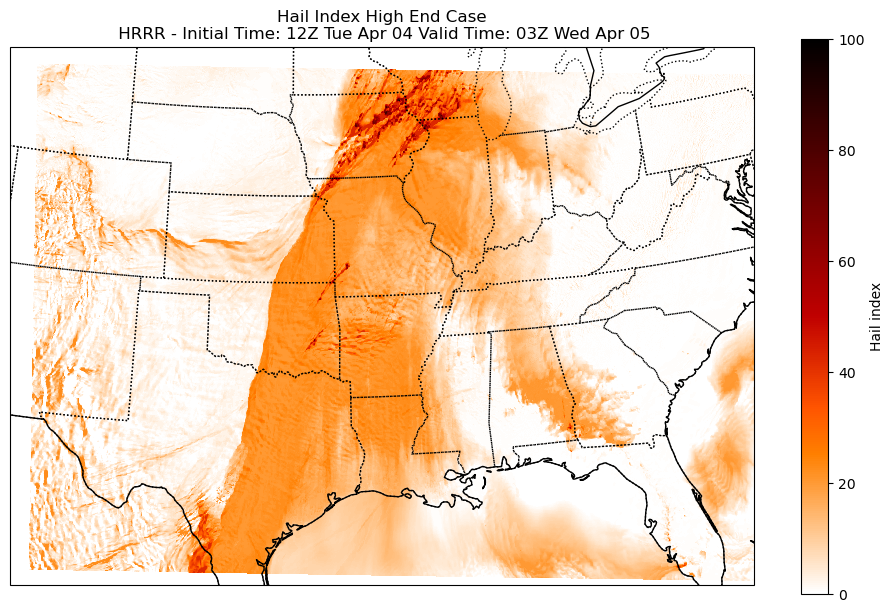

In [18]:
#making the hail index 
def hail_index_highend():
    hail_index_calc_highend = (cape_contribution_highend * 0.20 + refc_contribution_highend * 0.225 + vil_density_contribution_highend * .35 + vert_velo_contribution_highend * 0.225) * 100
    return hail_index_calc_highend

hail_index_highend()

#plotting the high end case
fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(lon, lat, hail_index_highend(), cmap = 'gist_heat_r' ,vmax = 100, transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of gist heat in reverse and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, label = 'Hail index', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size
ax.set_title(f"Hail Index High End Case\n HRRR - Initial Time: {pd.to_datetime(ds_highend_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_highend_file['valid_time'].isel(valid_time=15).values):%HZ %a %b %d %Y}") #setting our title with the model type, initial time, valid time, and what it is plotting
plt.show() # Display the map

In [19]:
ds_lowend_file = xr.open_dataset("hrrr_2026040612.nc") #ds_lowend_file used to open the netcdf file for us to plot the second high end case
ds_lowend_file = ds_lowend_file.rename({"unknown":"cloudtop"}) #cloudtops shows up as unknown and renaming it makes the data set easier to work with

#5 hour rolling products for the high-end case
refc_5hr_rolling_lowend = ds_lowend_file["refc"].rolling(valid_time=5).max()
cape_5hr_rolling_lowend = ds_lowend_file["cape"].rolling(valid_time=5).max()
vert_velo_5hr_rolling_lowend = ds_lowend_file["wz"].rolling(valid_time=5).max()
veril_5hr_rolling_lowend =ds_lowend_file["veril"].rolling(valid_time=5).max()
#derived products for high end
vil_density_lowend =  (ds_lowend_file["veril"] /  ds_lowend_file["cloudtop"]) *100
vil_density_5hr_rolling_lowend = vil_density_lowend.rolling(valid_time=5).max()

sh: 1: getfattr: not found


In [20]:
#making the individual indecies for the high end case
# Start with all contributions set to 0 for vil density
vil_density_5hr_rolling_lowend_time = vil_density_5hr_rolling_lowend.isel(valid_time=5).values
vil_density_contribution_lowend = np.zeros_like(vil_density_5hr_rolling_lowend_time)


mask = (vil_density_5hr_rolling_lowend_time >= 0.25) & (vil_density_5hr_rolling_lowend_time < 1.75 )
vil_density_contribution_lowend[mask] = (vil_density_5hr_rolling_lowend_time[mask] - 0.25) / 1.50

mask = (vil_density_5hr_rolling_lowend_time >= 1.75) 
vil_density_contribution_lowend[mask] = 1

#refc index
refc_5hr_rolling_lowend_time = refc_5hr_rolling_lowend.isel(valid_time=5).values
refc_contribution_lowend = np.zeros_like(refc_5hr_rolling_lowend_time)

# Setting the index = 0 if reflectivity is less than 45 
mask = refc_5hr_rolling_lowend_time < 45
refc_contribution_lowend[mask] = 0

# Creating a linearly increasing index from 0 to 1, for reflectivity in betwene 45 and 60 (inclusive)
mask = (refc_5hr_rolling_lowend_time >= 45) & (refc_5hr_rolling_lowend_time <= 60)
refc_contribution_lowend[mask] = ((refc_5hr_rolling_lowend_time[mask] - 45) / 15)

# Setting the index = 1 if reflectivty is greater than 60
mask = refc_5hr_rolling_lowend_time > 60
refc_contribution_lowend[mask] = 1

#cape index
cape_5hr_rolling_lowend_time = cape_5hr_rolling_lowend.isel(valid_time=5).values
cape_contribution_lowend = np.zeros_like(cape_5hr_rolling_lowend_time)

# Setting the index = 0 if CAPE is less than 1250
mask = (cape_5hr_rolling_lowend_time < 1250)
cape_contribution_lowend[mask] = 0

# Creating a linearly increasing index from 0 to 1, for CAPE in between 1250 and 2500 (inclusive)
mask = (cape_5hr_rolling_lowend_time >= 1250) & (cape_5hr_rolling_lowend_time <= 2500)
cape_contribution_lowend[mask] = (cape_5hr_rolling_lowend_time[mask] - 1250) / 1250

# Setting the index = 1 if CAPE is greater than 2500
mask = cape_5hr_rolling_lowend_time > 2500
cape_contribution_lowend[mask] = 1

#vertical velocity parameter index
vert_velo_5hr_rolling_lowend_time = vert_velo_5hr_rolling_lowend.isel(valid_time=5).values
vert_velo_contribution_lowend = np.zeros_like(vert_velo_5hr_rolling_lowend_time)

mask = (vert_velo_5hr_rolling_lowend_time >= 0) & (vert_velo_5hr_rolling_lowend_time < 0.55)
vert_velo_contribution_lowend[mask] = (vert_velo_5hr_rolling_lowend_time[mask] - 0) / 1.45

mask = (vert_velo_5hr_rolling_lowend_time >= 0.55) & (vert_velo_5hr_rolling_lowend_time < 1.2)
vert_velo_contribution_lowend[mask] = (vert_velo_5hr_rolling_lowend_time[mask] - 0.20) / 1

mask = (vert_velo_5hr_rolling_lowend_time >= 1.2)
vert_velo_contribution_lowend[mask] = 1

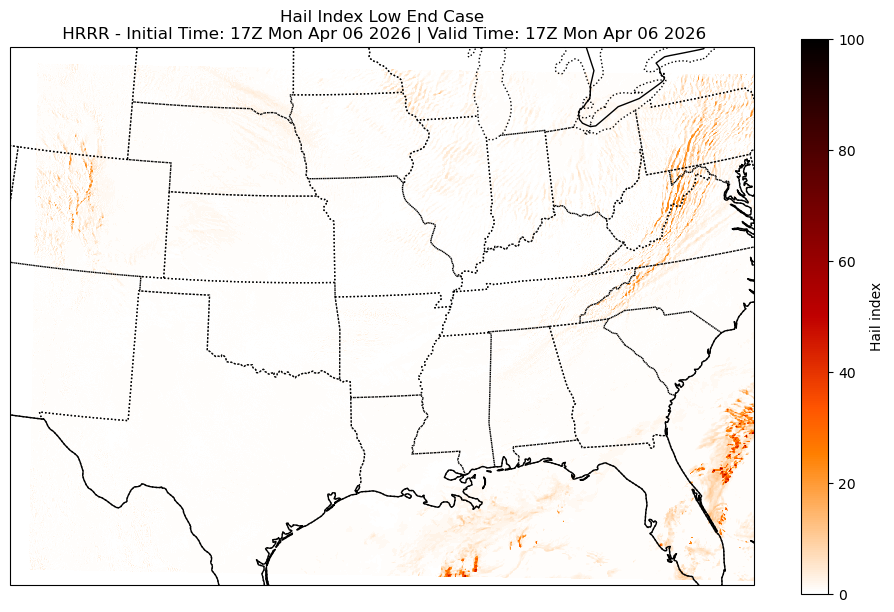

In [30]:
#making the hail index 
def hail_index_lowend():
    hail_index_calc_lowend = (cape_contribution_lowend * 0.20 + refc_contribution_lowend * 0.225 + vil_density_contribution_lowend * .35 + vert_velo_contribution_lowend * 0.225) * 100
    return hail_index_calc_lowend

hail_index_lowend()

#plotting the high end case
fig, ax = map() #printing out the base map funtion we created above
pcolor = ax.pcolormesh(lon, lat, hail_index_lowend(), cmap = 'gist_heat_r',vmax = 100, transform =ccrs.PlateCarree()) #creating the pcolor mesh with the valid_time of 15 with the color map of gist heat in reverse and adding longitude and latitude.
plt.colorbar(pcolor, ax=ax, label = 'Hail index', shrink = 0.8) #creating a colorbar for our map and shrinking it to a respectable size
ax.set_title(f"Hail Index Low End Case\n HRRR - Initial Time: {pd.to_datetime(ds_lowend_file['valid_time'].isel(valid_time=5).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_lowend_file['valid_time'].isel(valid_time=5).values):%HZ %a %b %d %Y}") #setting our title with the model type, initial time, valid time, and what it is plotting
plt.show() # Display the map

# Evaluating our Algorithm's Performance

Worked on by Jonathan.

- Did it produce reasonable values?

Yes, our algorithm produced reasonable values. For the high end case, the algorithm did a commendable job identifying various areas where there were clusters of hail reports. For example, areas such as Central Iowa, Northwestern Illinois, and Southwestern Missouri were all identified by the algorithm as zones with a particularly high hail index, which correlates with a myriad of storm reports in those zones. The algorithm did a good job of identifying the larger area where hail was a possibility - this heightened area extended from Texas to Wisconsin, which is very similar to the broader swath of hail reports seen on the map. As for the lower end case, the hail index algorithm produced realistically small values (which makes sense, given the fact that there were 0 hail reports). The highest (although still very small) values were found near high elevations, which makes sense given the elevated vertical velocity. 

- Were there false alarms or missed threats?

The hail index uses 5-hour rolling time, and the event on April 4, 2023 happened over a far longer duration than 5 hours. Therefore, it struggled to capture some of the convective initiation that occured outside that period. The slightly higher (yet still low) values of the hail index in Pennsylvania, especially, in the low end case is pretty much a false alarm. The only reason the hail index is being slightly activated is because of higher vertical velocity values because of higher elevations.

- Did you need to revise the formula? If so, how?

We did not need to revise the formula. The above problems do not occur due to the algorithmic merit of our index, but rather unusual features of each day. The high end event occurred over a far longer time period than a usual event. As for vertical velocity issues, we already do not weight it particularly heavily to account for the above issues. We didn't lower its weighting because when it's not an elevation-induced false alarm, it proves to provide a fantastic correlation with hail probability.   

# Automating Plot Generation

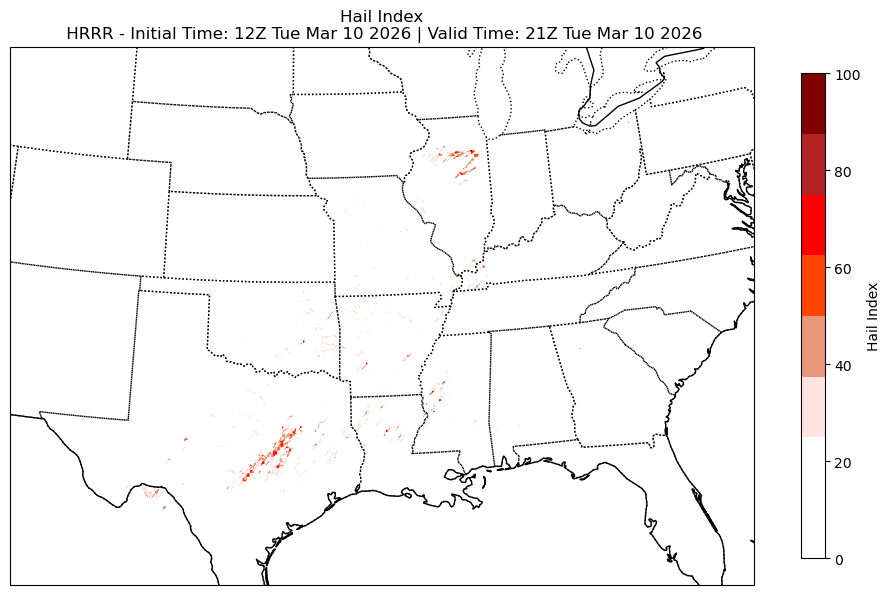

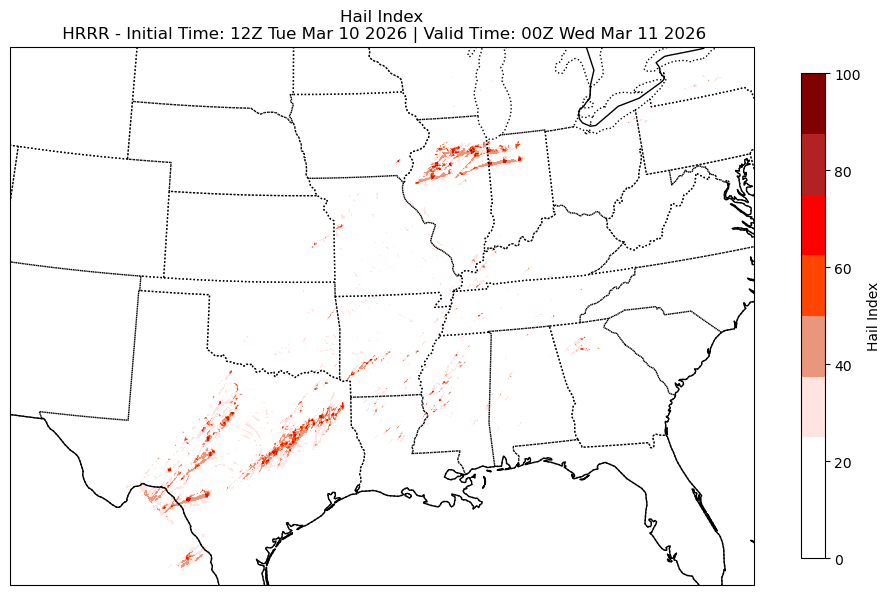

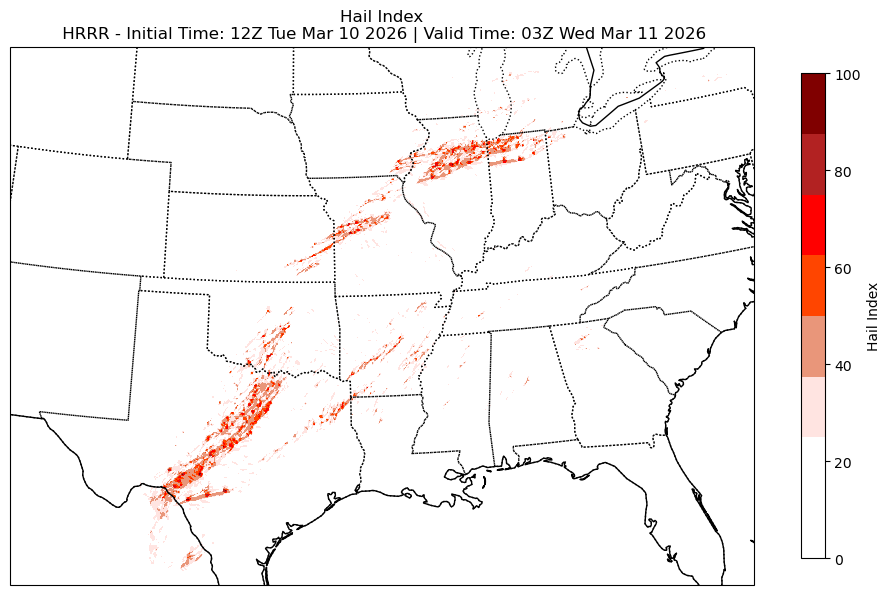

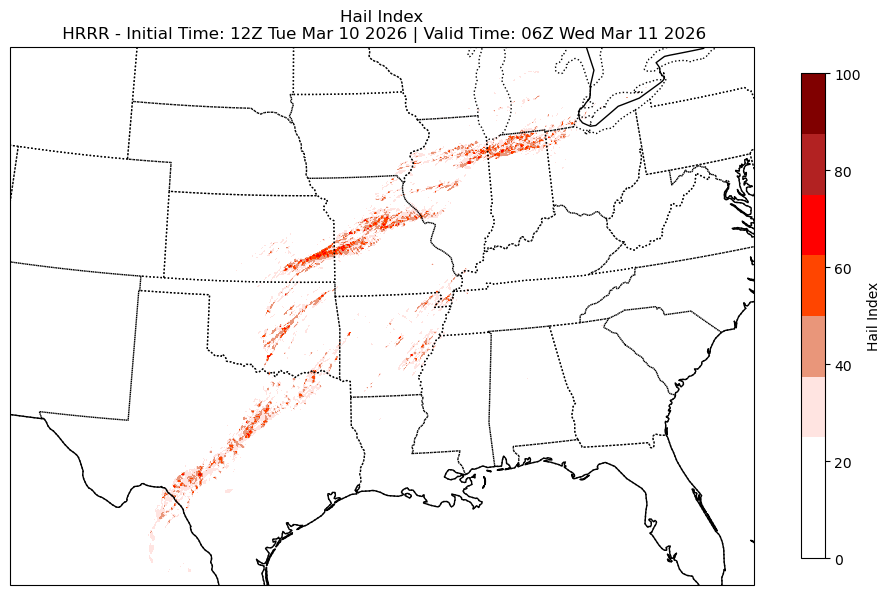

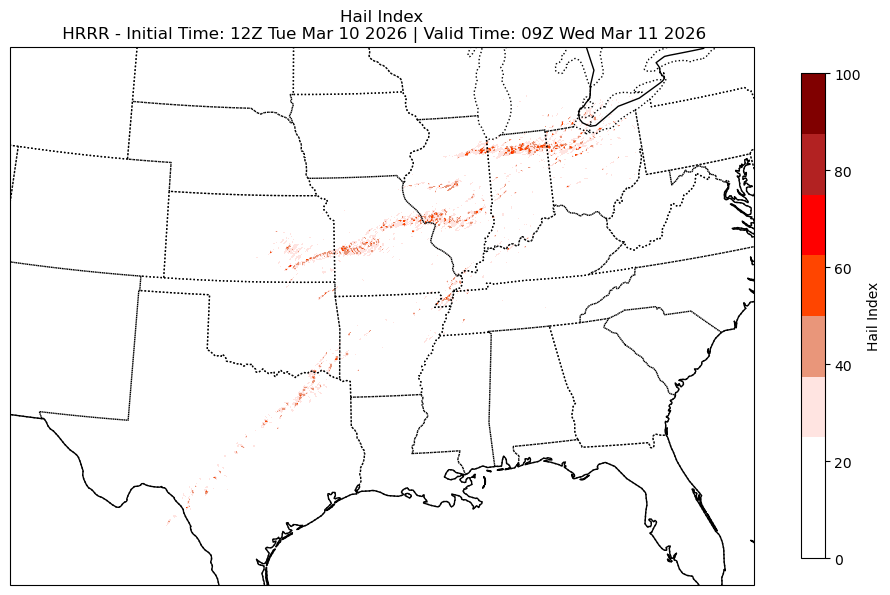

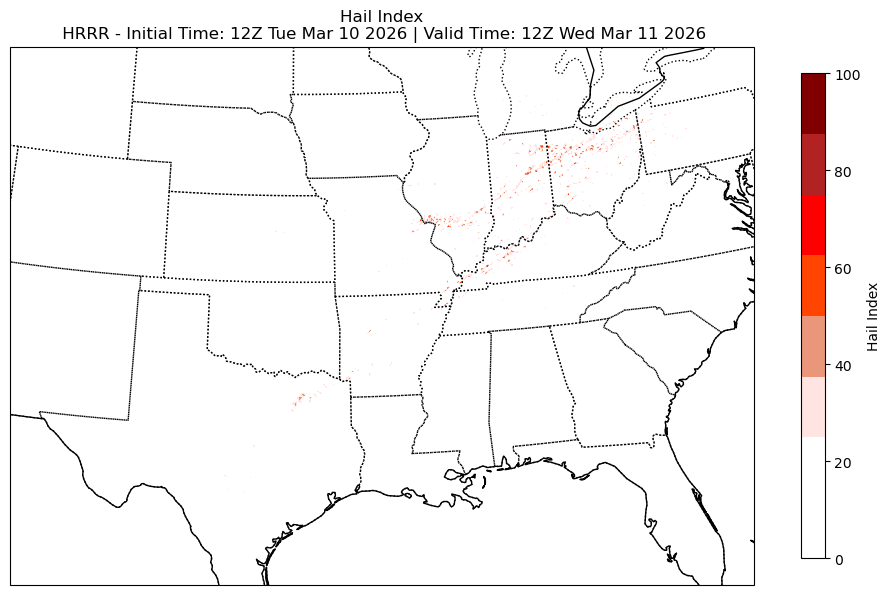

In [31]:
#Code to automate plot generation worked on by Myles
for i in [9,12,15,18,21,24]: #creating for loop over time of the 6 time steps we plotted
    fig, axes = map() #calling map function
    pcolor4 = axes.pcolormesh(lon, lat, hail_index(ds_file,i), cmap = realcmap, vmax = 100, transform = dataproj) #creating a pcolormesh map for hail index at step 9
    plt.colorbar(pcolor4, ax=axes, label = 'Hail Index', shrink = 0.7) #creating colorbar for the map
    axes.set_title(f"Hail Index\n HRRR - Initial Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=0).values):%HZ %a %b %d %Y} | Valid Time: {pd.to_datetime(ds_file['valid_time'].isel(valid_time=i).values):%HZ %a %b %d %Y}") #title for map at step 9 with model name, valid time and initial time
    file_name = "Hail_Index_{0:03d}.png".format(i) #creating hail index file name and formatting it so it can be in terms of time
    plt.savefig(file_name) #saving hail index figs with the file name format

# Converting Code to Python Script

In [23]:
#Converting code from Jupyter Notebook to a standalone Python script worked on by Manuel. Can locate it in our directory.